On commence par définir les deux fonctions, pour le calcul des deux scores : Dice et IoU. Ensuite, on charge la base de données Oxford avec les images des chats et des chiens.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from skimage import color
from skimage.filters import gaussian
from skimage.segmentation import (
    morphological_geodesic_active_contour,
    inverse_gaussian_gradient,
    checkerboard_level_set
)
def dice_score(gt, seg):
    intersection = np.sum(gt * seg)
    total_area = np.sum(gt) + np.sum(seg)
    return (2.0 * intersection) / total_area if total_area > 0 else 1.0

def iou_score(gt, seg):
    intersection = np.sum(gt * seg)
    union = np.sum(gt) + np.sum(seg) - intersection
    return intersection / union if union > 0 else 1.0
print("Chargement du dataset Oxford Pet...")
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True, split='train')

Chargement du dataset Oxford Pet...


*   Dans cette partie, on commence par extraire le mask de l'image de la base de donnée.
*   Ensuite, une étape de prètraitement : convertir l'image de RGB en une image en noir et blanc avec la fonction rgb2gray(), et on rajoute du bruit gaussien avec la fonction gaussien().
*   On commence maintenant l'algorithme par le calcul de l'inverse du gradient (critère d'arrêt), et on initialise une courbe grossièrement. On rentre dans la fonction morphological_geodesique_active_contour() dans laquelle on initialise le nombre d'itération et les paramètres smoothing et balloon.
*   On calcul les deux scores Dice et IoU sur les 50 premières images de la base de données.
*   On affiche le masque et le résultat sur une image de la base de données.





Calcul des métriques sur 50 images...
Génération du visuel pour la première image...


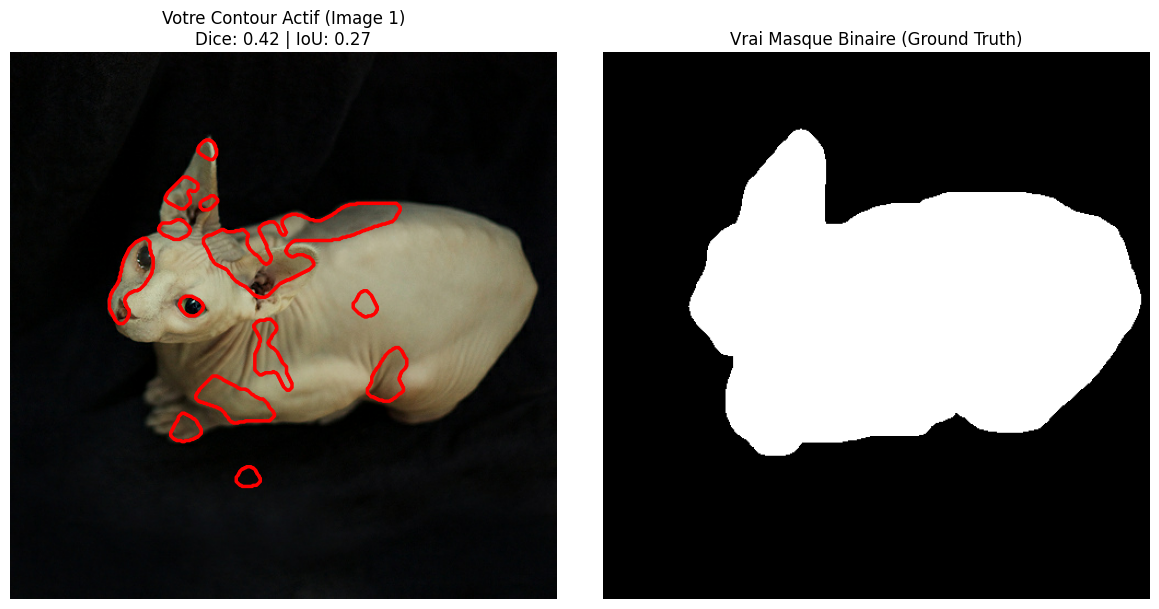

Progression : 10/50 images évaluées...
Progression : 20/50 images évaluées...
Progression : 30/50 images évaluées...
Progression : 40/50 images évaluées...
Progression : 50/50 images évaluées...

 SCORE MOYEN SUR 50 IMAGES DU DATASET
Dice Score Moyen : 0.5516 (55.16%)
IoU Moyen        : 0.4016 (40.16%)


In [ ]:
dice_list = []
iou_list = []
nb_images = 50
print(f"Calcul des métriques sur {nb_images} images...")
for i, item in enumerate(dataset.take(nb_images)):
    img_color = item['image'].numpy()
    tf_mask = item['segmentation_mask'].numpy().squeeze()
    gt = np.where((tf_mask == 1) | (tf_mask == 3), 1, 0)
    img_gray = color.rgb2gray(img_color)
    img_smoothed = gaussian(img_gray, sigma=4)
    gimage = inverse_gaussian_gradient(img_smoothed, alpha=120)

    init_ls = checkerboard_level_set(img_gray.shape, 6)
    ls = morphological_geodesic_active_contour(
        gimage,
        num_iter=250,
        init_level_set=init_ls,
        smoothing=3,
        balloon=-1
    )
    seg = np.where(ls <= 0.5, 1, 0)
    dice_list.append(dice_score(gt, seg))
    iou_list.append(iou_score(gt, seg))
    if i == 0:
        print("Génération du visuel pour la première image...")
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(img_color)
        axes[0].contour(ls, [0.5], colors='red', linewidths=2.5)
        axes[0].set_title(f"Votre Contour Actif (Image 1)\nDice: {dice_list[0]:.2f} | IoU: {iou_list[0]:.2f}")
        axes[0].axis('off')
        axes[1].imshow(gt, cmap='gray')
        axes[1].set_title("Vrai Masque Binaire (Ground Truth)")
        axes[1].axis('off')
        plt.tight_layout()
        plt.show(block=False)

    if (i + 1) % 10 == 0:
        print(f"Progression : {i + 1}/{nb_images} images évaluées...")


mean_dice = np.mean(dice_list)
mean_iou = np.mean(iou_list)

print("\n" + "="*45)
print(f" SCORE MOYEN SUR {nb_images} IMAGES DU DATASET")
print("="*45)
print(f"Dice Score Moyen : {mean_dice:.4f} ({mean_dice * 100:.2f}%)")
print(f"IoU Moyen        : {mean_iou:.4f} ({mean_iou * 100:.2f}%)")
print("="*45)
plt.show()

On a voulu tester l'algorithme sur une image synthétique (carée noire sur un fond blanc), dans ce cas, on a diminué le nombre d'itérations et le smoothing car on a une image plutôt simple. On a remarqué que lorsqu'on initialise d'une manière aléatoire, on obtient un mauvais résultat.

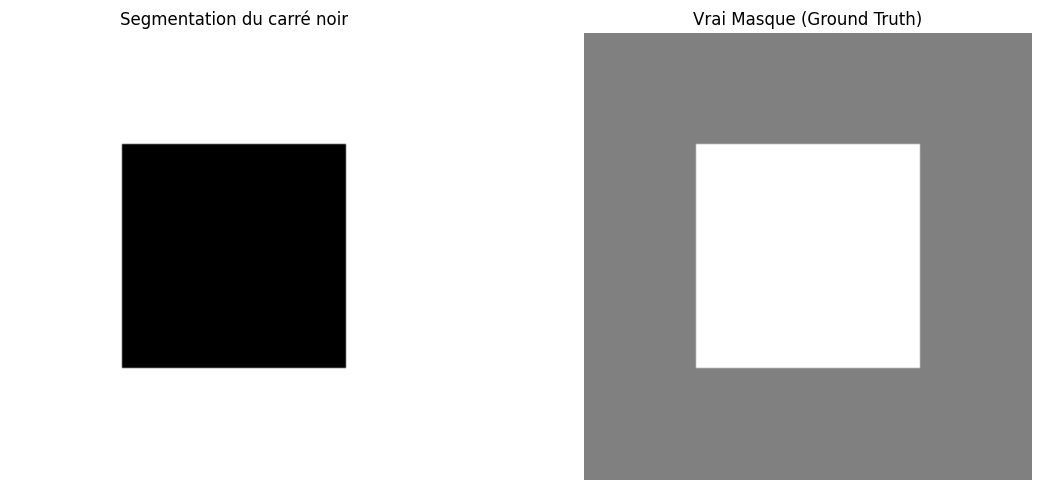


     RÉSULTATS IMAGE SYNTHÉTIQUE     
Dice Score : 0.4000 (40.00%)
IoU Score  : 0.2500 (25.00%)


In [ ]:
image_synth = np.ones((200, 200), dtype=np.float32)
image_synth[50:150, 50:150] = 0.0
gt_synth = np.zeros((200, 200), dtype=np.int32)
gt_synth[50:150, 50:150] = 1
img_smoothed = gaussian(image_synth, sigma=1)
gimage = inverse_gaussian_gradient(img_smoothed, alpha=100)
init_ls = checkerboard_level_set(image_synth.shape, 6)
ls = morphological_geodesic_active_contour(
    gimage,
    num_iter=150,
    init_level_set=init_ls,
    smoothing=1,
    balloon=-1
)
seg_synth = np.where(ls <= 0.5, 1, 0)
dice_synth = dice_score(gt_synth, seg_synth)
iou_synth = iou_score(gt_synth, seg_synth)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_synth, cmap='gray')
axes[0].contour(ls, [0.5], colors='red', linewidths=3)
axes[0].set_title("Segmentation du carré noir")
axes[0].axis('off')
axes[1].imshow(gt_synth, cmap='gray', alpha=0.5)
axes[1].set_title("Vrai Masque (Ground Truth)")
axes[1].axis('off')
plt.tight_layout()
plt.show()
print("\n" + "="*35)
print("     RÉSULTATS IMAGE SYNTHÉTIQUE     ")
print("="*35)
print(f"Dice Score : {dice_synth:.4f} ({dice_synth * 100:.2f}%)")
print(f"IoU Score  : {iou_synth:.4f} ({iou_synth * 100:.2f}%)")
print("="*35)

On remarque que lorsqu'on initialise avec un contour externe, l'algorithme converge vers l'objet et prend la forme exacte de son contour.


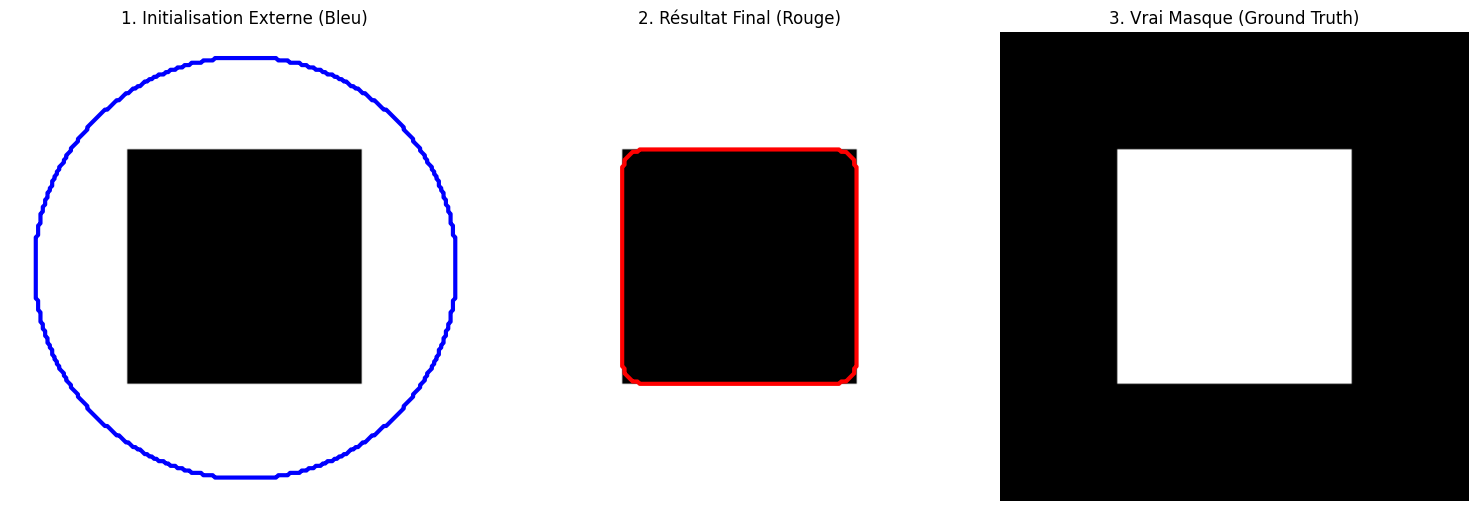


     RÉSULTATS DU CONTOUR EXTERNE     
Dice Score : 0.0038 (0.38%)
IoU Score  : 0.0019 (0.19%)


In [ ]:
from skimage.segmentation import (
    morphological_geodesic_active_contour,
    inverse_gaussian_gradient,
    disk_level_set
)
image_synth = np.ones((200, 200), dtype=np.float32)
image_synth[50:150, 50:150] = 0.0
gt_synth = np.zeros((200, 200), dtype=np.int32)
gt_synth[50:150, 50:150] = 1
img_smoothed = gaussian(image_synth, sigma=1.0)
gimage = inverse_gaussian_gradient(img_smoothed, alpha=100)
init_ls = disk_level_set(image_synth.shape, center=(100, 100), radius=90)
ls = morphological_geodesic_active_contour(
    gimage,
    num_iter=100,
    init_level_set=init_ls,
    smoothing=1,
    balloon=-1
)
seg_synth = np.where(ls <= 0.5, 1, 0)
dice_synth = dice_score(gt_synth, seg_synth)
iou_synth = iou_score(gt_synth, seg_synth)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_synth, cmap='gray')
axes[0].contour(init_ls, [0.5], colors='blue', linewidths=3)
axes[0].set_title("Initialisation Externe (Bleu)")
axes[0].axis('off')
axes[1].imshow(image_synth, cmap='gray')
axes[1].contour(ls, [0.5], colors='red', linewidths=3)
axes[1].set_title("Résultat Final (Rouge)")
axes[1].axis('off')
axes[2].imshow(gt_synth, cmap='gray')
axes[2].set_title(" Vrai Masque (Ground Truth)")
axes[2].axis('off')
plt.tight_layout()
plt.show()
print("\n" + "="*35)
print("     RÉSULTATS DU CONTOUR EXTERNE     ")
print("="*35)
print(f"Dice Score : {dice_synth:.4f} ({dice_synth * 100:.2f}%)")
print(f"IoU Score  : {iou_synth:.4f} ({iou_synth * 100:.2f}%)")
print("="*35)